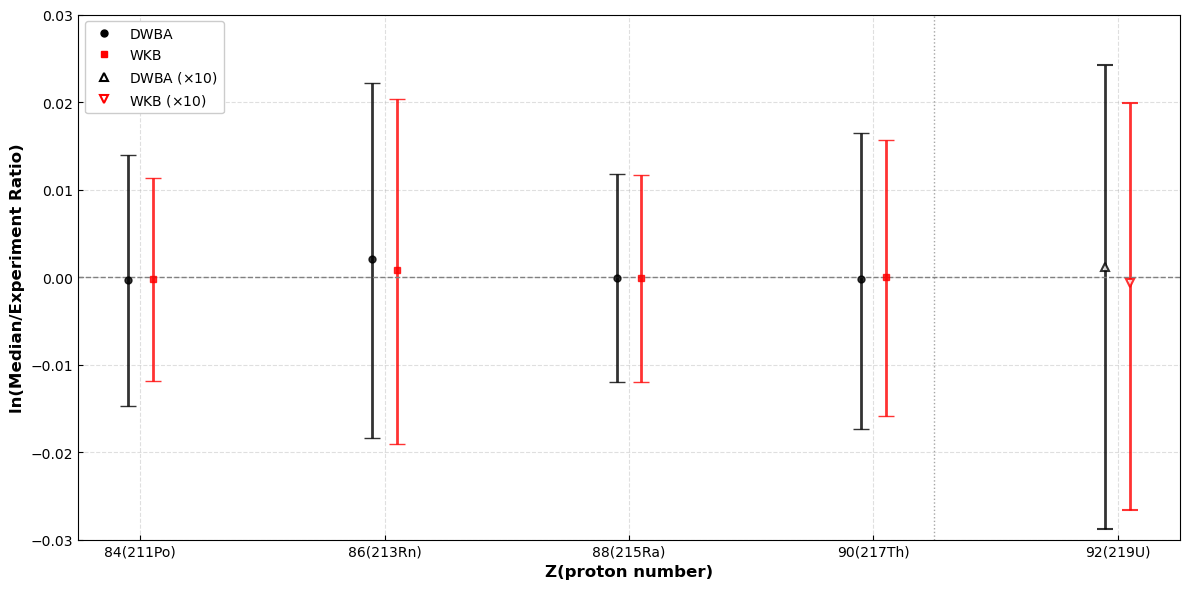

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Sys=['211Po','213Rn','215Ra','217Th','219U']
Z=[84,86,88,90,92]
T_half_expt=[0.516,19.36e-3,1.68e-3,254e-6,60e-6]
T_half_calc_dwba=[0.515853576464293,0.01940080074073156,0.0016798746921742062,0.00025393277540573426,6.0724287680416717e-05]
T_half_2sigma_dwba=[0.007384161900277197,0.0003937785991267398,1.999598301277089e-05,4.292253948313664e-06,1.5754327577762725e-05]

T_half_calc_wkb=[0.5158905614040402,0.019376367726007926,0.0016799052057963173,0.0002540000639797968,5.960557474881356e-05]
T_half_2sigma_wkb=[0.005965097512233266,0.0003818913474164974,1.9873828913767867e-05,4.0074559194984095e-06,1.3631900306087726e-05]

# 计算两种模型的比值和误差
ratios_dwba = [np.log(calc/expt) for calc, expt in zip(T_half_calc_dwba, T_half_expt)]
ratio_errors_dwba = [np.log(sigma/expt) for sigma, expt in zip(T_half_2sigma_dwba, T_half_expt)]
ratios_wkb = [np.log(calc/expt) for calc, expt in zip(T_half_calc_wkb, T_half_expt)] 
ratio_errors_wkb = [np.log(sigma/expt) for sigma, expt in zip(T_half_2sigma_wkb, T_half_expt)]

# 计算对数转换后的误差范围（上界和下界）
error_dwba_lower = [np.log((calc-sigma)/expt) for calc, sigma, expt in zip(T_half_calc_dwba, T_half_2sigma_dwba, T_half_expt)]
error_dwba_upper = [np.log((calc+sigma)/expt) for calc, sigma, expt in zip(T_half_calc_dwba, T_half_2sigma_dwba, T_half_expt)]
error_wkb_lower = [np.log((calc-sigma)/expt) for calc, sigma, expt in zip(T_half_calc_wkb, T_half_2sigma_wkb, T_half_expt)]
error_wkb_upper = [np.log((calc+sigma)/expt) for calc, sigma, expt in zip(T_half_calc_wkb, T_half_2sigma_wkb, T_half_expt)]

# 准备误差条数据（上误差和下误差）
dwba_errors = [np.array(ratios_dwba) - np.array(error_dwba_lower), 
               np.array(error_dwba_upper) - np.array(ratios_dwba)]
wkb_errors = [np.array(ratios_wkb) - np.array(error_wkb_lower),
              np.array(error_wkb_upper) - np.array(ratios_wkb)]

# 创建第一个图形（所有核素，但219U的数据除以10）
plt.figure(figsize=(12, 6))

# 绘制前四个核素的DWBA模型结果
plt.errorbar(np.array(Z[:4])-0.1, ratios_dwba[:4], yerr=[err[:4] for err in dwba_errors], fmt='o', 
            color='black', markersize=5, capsize=6, label='DWBA', 
            linewidth=2, alpha=0.8)

# 绘制前四个核素的WKB模型结果
plt.errorbar(np.array(Z[:4])+0.1, ratios_wkb[:4], yerr=[err[:4] for err in wkb_errors], fmt='s',
            color='red', markersize=5, capsize=6, label='WKB',
            linewidth=2, alpha=0.8)

# 绘制219U的数据（实际值除以10）
plt.errorbar([Z[-1]-0.1], [ratios_dwba[-1] / 10], yerr=[[dwba_errors[0][-1] / 10], [dwba_errors[1][-1] / 10]], fmt='^', 
            color='black', markersize=6, capsize=6, 
            linewidth=2, alpha=0.8, markerfacecolor='white', markeredgewidth=1.5)

plt.errorbar([Z[-1]+0.1], [ratios_wkb[-1] / 10], yerr=[[wkb_errors[0][-1] / 10], [wkb_errors[1][-1] / 10]], fmt='v',
            color='red', markersize=6, capsize=6, 
            linewidth=2, alpha=0.8, markerfacecolor='white', markeredgewidth=1.5)

# 添加参考线
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# 设置坐标轴
all_Z = Z[:4] + [Z[-1]]
all_labels = [f"{z}({sys})" for z, sys in zip(Z[:4], Sys[:4])] + [f"{Z[-1]}({Sys[-1]})"]
plt.xticks(all_Z, all_labels, fontsize=10)
plt.xlabel('Z(proton number)', fontsize=12, fontweight='bold')
plt.ylabel('ln(Median/Experiment Ratio)', fontsize=12, fontweight='bold')

# 设置纵坐标轴
ax1 = plt.gca()
ax1.set_ylim(-0.03, 0.03)

# 添加刻度线在坐标轴内侧
ax1.tick_params(axis='both', direction='in', which='both')

# 添加分隔线区分219U数据
plt.axvline(x=90.5, color='gray', linestyle=':', linewidth=1, alpha=0.7)

# 添加图例 - 修正图例元素
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='black', markersize=5, label='DWBA', linestyle='', markerfacecolor='black'),
    plt.Line2D([0], [0], marker='s', color='red', markersize=5, label='WKB', linestyle='', markerfacecolor='red'),
    plt.Line2D([0], [0], marker='^', color='black', markersize=6, label='DWBA ($\\times 10$)', linestyle='', 
               markerfacecolor='white', markeredgewidth=1.5),
    plt.Line2D([0], [0], marker='v', color='red', markersize=6, label='WKB ($\\times 10$)', linestyle='',
               markerfacecolor='white', markeredgewidth=1.5)
]
plt.legend(handles=legend_elements, fontsize=10, loc='upper left', framealpha=1)

# 添加网格
ax1.grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.savefig('comparison_all_with_219U_divided.pdf')
plt.show()